<a href="https://colab.research.google.com/github/syedmahmoodiagents/computervision/blob/main/UNet_Tensorflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import tensorflow_datasets as tfds

# Upsampling

In [ ]:

input = tf.random.normal((1, 8, 8, 128))

up = layers.Conv2DTranspose(64, kernel_size=3, strides=4, padding='same')(input)
print(up.shape)


(1, 32, 32, 64)


# AutoEncoders

In [ ]:
def simple_encoder_decoder(input_shape=(128, 128, 3), num_classes=1):
    inputs = layers.Input(shape=input_shape)


    x = layers.Conv2D(16, 3, padding='same', activation='relu')(inputs)
    x = layers.MaxPooling2D(2)(x)  # 64x64

    x = layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D(2)(x)  # 32x32
    print(x.shape)
    # Bottleneck ---
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    print(x.shape)

    x = layers.Conv2DTranspose(32, 3, strides=2, padding='same', activation='relu')(x)  # 64x64
    print(x.shape)
    x = layers.Conv2DTranspose(16, 3, strides=2, padding='same', activation='relu')(x)  # 128x128
    print(x.shape)

    if num_classes == 1:
        activation = 'sigmoid'
    else:
        activation = 'softmax'

    outputs = layers.Conv2D(num_classes, 1, activation=activation)(x)

    return models.Model(inputs, outputs)


In [ ]:
model = simple_encoder_decoder()

(None, 32, 32, 32)
(None, 32, 32, 64)
(None, 64, 64, 32)
(None, 128, 128, 16)


In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 64, 64, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 128, 128, 16)   │         4,624 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 1)    │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,689 (182.38 KB)

 Trainable params: 46,689 (182.38 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
X = np.random.rand(10, 128, 128, 3)
y = np.random.choice([0,1], (10, 128, 128, 1))

In [ ]:
y.shape

(10, 128, 128, 1)

In [ ]:
model.fit(X, y, epochs=3)


Epoch 1/3
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.5030 - loss: 0.6932
Epoch 2/3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.5037 - loss: 0.6931
Epoch 3/3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.5054 - loss: 0.6931


# Concatenation

In [ ]:

decoder_tensor = tf.random.uniform(shape=(1, 8, 8, 100), minval=0, maxval=256, dtype=tf.int32) # Example range
encoder_tensor = tf.random.uniform(shape=(1, 8, 8, 200), minval=0, maxval=256, dtype=tf.int32) # Example range


output = tf.keras.layers.concatenate([decoder_tensor, encoder_tensor])

print(output.shape)

(1, 8, 8, 300)


# Unet Code

In [ ]:

def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
    x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
    return x

def encoder_block(x, filters):
    f = conv_block(x, filters)
    p = layers.MaxPooling2D(pool_size=(2, 2))(f)
    return f, p  # return both for skip connection

def decoder_block(x, skip, filters):
    x = layers.Conv2DTranspose(filters, 2, strides=2, padding='same')(x)
    x = layers.Concatenate()([x, skip])
    x = conv_block(x, filters)
    return x

#  U-Net Model ---
def build_unet(input_shape=(128, 128, 3), num_classes=1):
    inputs = layers.Input(input_shape)


    s1, p1 = encoder_block(inputs, 64)   # -> 64x64
    print(s1.shape, p1.shape)
    s2, p2 = encoder_block(p1, 128)      # -> 32x32
    print(s1.shape, p1.shape)
    s3, p3 = encoder_block(p2, 256)      # -> 16x16
    s4, p4 = encoder_block(p3, 512)      # -> 8x8

    # --- Bottleneck ---
    b = conv_block(p4, 1024)             # -> 8x8


    d1 = decoder_block(b, s4, 512)       # -> 16x16
    d2 = decoder_block(d1, s3, 256)      # -> 32x32
    d3 = decoder_block(d2, s2, 128)      # -> 64x64
    d4 = decoder_block(d3, s1, 64)       # -> 128x128


    if num_classes == 1:
        activation = 'sigmoid'
    else:
        activation = 'softmax'

    outputs = layers.Conv2D(num_classes, 1, padding='same', activation=activation)(d4)

    return models.Model(inputs, outputs)


In [ ]:
model = build_unet(input_shape=(128, 128, 3), num_classes=1)


In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 64, 64, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 128, 128, 16)   │         4,624 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 1)    │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 140,069 (547.15 KB)

 Trainable params: 46,689 (182.38 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 93,380 (364.77 KB)

In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
model.fit(X, y, epochs=3)


Epoch 1/3
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.5011 - loss: 0.6931
Epoch 2/3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.5044 - loss: 0.6931
Epoch 3/3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.5052 - loss: 0.6931


# On oxford_iiit_pet dataset

In [ ]:
ds, info = tfds.load("oxford_iiit_pet:4.0.0", with_info=True)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.140MK6_4.0.0/oxford_iiit_pet-train.tfrecord*...…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.140MK6_4.0.0/oxford_iiit_pet-test.tfrecord*...:…

Dataset oxford_iiit_pet downloaded and prepared to /root/tensorflow_datasets/oxford_iiit_pet/4.0.0. Subsequent calls will reuse this data.


In [ ]:
print(info.features['label'].names)
print(info.features['species'].names)

['Abyssinian', 'american_bulldog', 'american_pit_bull_terrier', 'basset_hound', 'beagle', 'Bengal', 'Birman', 'Bombay', 'boxer', 'British_Shorthair', 'chihuahua', 'Egyptian_Mau', 'english_cocker_spaniel', 'english_setter', 'german_shorthaired', 'great_pyrenees', 'havanese', 'japanese_chin', 'keeshond', 'leonberger', 'Maine_Coon', 'miniature_pinscher', 'newfoundland', 'Persian', 'pomeranian', 'pug', 'Ragdoll', 'Russian_Blue', 'saint_bernard', 'samoyed', 'scottish_terrier', 'shiba_inu', 'Siamese', 'Sphynx', 'staffordshire_bull_terrier', 'wheaten_terrier', 'yorkshire_terrier']
['Cat', 'Dog']


In [ ]:
ds['train'].element_spec

{'file_name': TensorSpec(shape=(), dtype=tf.string, name=None),
 'head_bbox': TensorSpec(shape=(4,), dtype=tf.float32, name=None),
 'image': TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None),
 'label': TensorSpec(shape=(), dtype=tf.int64, name=None),
 'segmentation_mask': TensorSpec(shape=(None, None, 1), dtype=tf.uint8, name=None),
 'species': TensorSpec(shape=(), dtype=tf.int64, name=None)}

In [ ]:
# for image_batch, mask_batch in ds.take(1):
#     # Iterate through each image and mask in the batch
#     for i in range(tf.shape(image_batch)[0]):
#         image = image_batch[i]
#         mask = mask_batch[i]

#         plt.figure(figsize=(12, 4))
#         plt.subplot(1, 2, 1)
#         plt.imshow(image)
#         plt.title("Image")

#         plt.subplot(1, 2, 2)
#         plt.imshow(tf.squeeze(mask))
#         plt.title("True Mask")

In [ ]:
IMG_SIZE = 128

def normalize_image_mask(datapoint):
    image = tf.image.resize(datapoint["image"], (IMG_SIZE, IMG_SIZE))
    mask = tf.image.resize(datapoint["segmentation_mask"], (IMG_SIZE, IMG_SIZE), method="nearest")

    # Remap mask values to be 0, 1, or 2
    # Original values: 1 (pet), 2 (background), 3 (boundary)
    # New values:      1 (pet), 0 (background), 2 (boundary)
    mask = tf.where(mask == 2, tf.zeros_like(mask), mask) # Map 2 (background) to 0
    mask = tf.where(mask == 3, tf.ones_like(mask) * 2, mask) # Map 3 (boundary) to 2

    image = tf.cast(image, tf.float32) / 255.0
    mask = tf.cast(mask, tf.uint8) # Ensure mask remains uint8
    return image, mask

In [ ]:
ds_train_small = ds['train'].take(10).map(normalize_image_mask).batch(2).prefetch(tf.data.AUTOTUNE)

In [ ]:
ds_train_small.element_spec

(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None),
 TensorSpec(shape=(None, 128, 128, 1), dtype=tf.uint8, name=None))

In [ ]:
model = build_unet(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=3)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


(None, 128, 128, 64) (None, 64, 64, 64)
(None, 128, 128, 64) (None, 64, 64, 64)


In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │  1,180,160 │ max_pooling2d_2[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 16, 16,    │  2,359,808 │ conv2d_6[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 8, 8, 512) │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 8, 8,      │  4,719,616 │ max_pooling2d_3[… │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 8, 8,      │  9,438,208 │ conv2d_8[0][0]    │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 16, 16,    │  2,097,664 │ conv2d_9[0][0]    │
│ (Conv2DTranspose)   │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 16, 16,    │          0 │ conv2d_transpose

 Total params: 31,031,875 (118.38 MB)

 Trainable params: 31,031,875 (118.38 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.fit(ds_train_small, epochs=5)


Epoch 1/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step - accuracy: 0.5432 - loss: 1.1693
Epoch 2/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 19s 3s/step - accuracy: 0.6160 - loss: 1.0192
Epoch 3/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.5847 - loss: 1.0175
Epoch 4/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.6274 - loss: 0.9808
Epoch 5/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 14s 3s/step - accuracy: 0.6274 - loss: 0.9567


In [ ]:
import matplotlib.pyplot as plt

In [ ]:
def show_sample(dataset):
    for image_batch, mask_batch in dataset.take(1):
        # Iterate through each image and mask in the batch
        for i in range(tf.shape(image_batch)[0]):
            image = image_batch[i]
            mask = mask_batch[i]

            pred_mask = tf.argmax(model.predict(tf.expand_dims(image, 0)), axis=-1)[0]


            plt.figure(figsize=(12, 4))
            plt.subplot(2, 3, 1)
            plt.imshow(image)
            plt.title("Image")

            plt.subplot(2, 3, 2)
            plt.imshow(tf.squeeze(mask))
            plt.title("True Mask")

            plt.subplot(2, 3, 3)
            plt.imshow(tf.squeeze(pred_mask))
            plt.title("Predicted Mask")



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 522ms/step


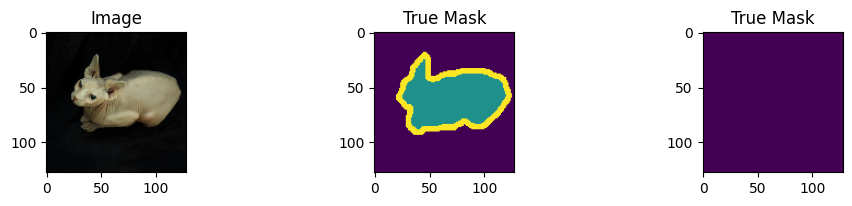

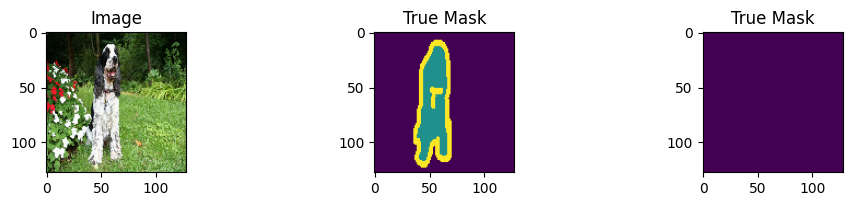

In [ ]:
show_sample(ds_train_small)

In [ ]:
print(info.features['label'].names)
print(info.features['species'].names)